Shape: (1040, 780, 3)
Data type: uint8


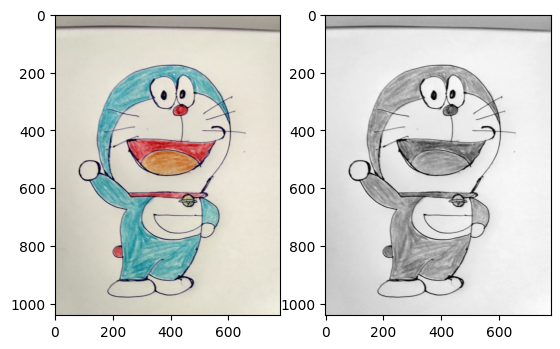

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('./Dora.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f"Shape: {img.shape}")
print(f"Data type: {img.dtype}")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.subplot(121), plt.imshow(img_rgb)
plt.subplot(122), plt.imshow(gray, cmap='gray')
plt.show()


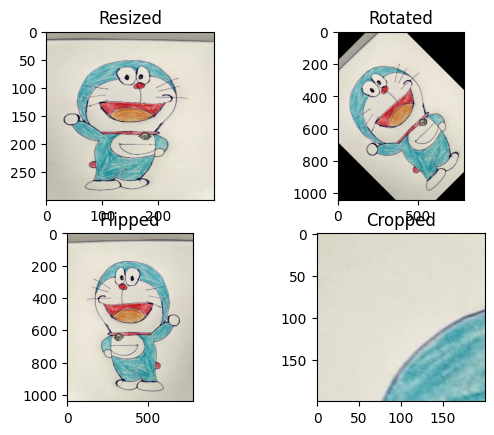

In [ ]:
### Exercise 2: Image Transformations

### **Objective:** Apply geometric transformations

### **Tasks to Complete:**
### 1. Resize images to different dimensions
### 2. Rotate images by various angles
### 3. Flip images (horizontal/vertical)
### 4. Crop specific regions of interest

resized = cv2.resize(img, (300, 300))

# Rotate
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

# Flip
flipped = cv2.flip(img, 1)  # 1=horizontal, 0=vertical

# Crop
cropped = img[100:300, 100:300]

# Display all transformations
plt.subplot(221), plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title('Resized')
plt.subplot(222), plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title('Rotated')
plt.subplot(223), plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title('Flipped')
plt.subplot(224), plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title('Cropped')
plt.show()

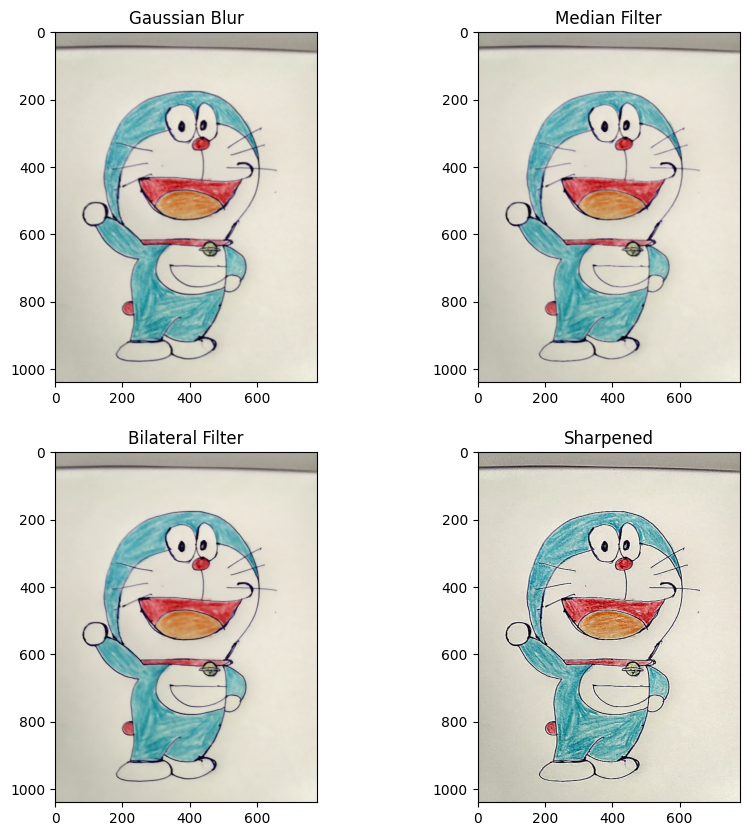

In [ ]:
## Section 2: Image Filtering & Enhancement

### Exercise 3: Applying Filters

### **Objective:** Implement various image filters

### **Tasks to Complete:**
### 1. Apply Gaussian blur for noise reduction
### 2. Use median filter for salt-and-pepper noise
### 3. Implement bilateral filter for edge preservation
### 4. Apply sharpening filters

import numpy as np

# Gaussian Blur
gaussian = cv2.GaussianBlur(img, (5, 5), 0)

# Median Filter
median = cv2.medianBlur(img, 5)

# Bilateral Filter (preserves edges)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

# Sharpening kernel
kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])
sharpened = cv2.filter2D(img, -1, kernel)

# Display results
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Gaussian Blur')
axes[0, 1].imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Median Filter')
axes[1, 0].imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Bilateral Filter')
axes[1, 1].imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Sharpened')
plt.show()

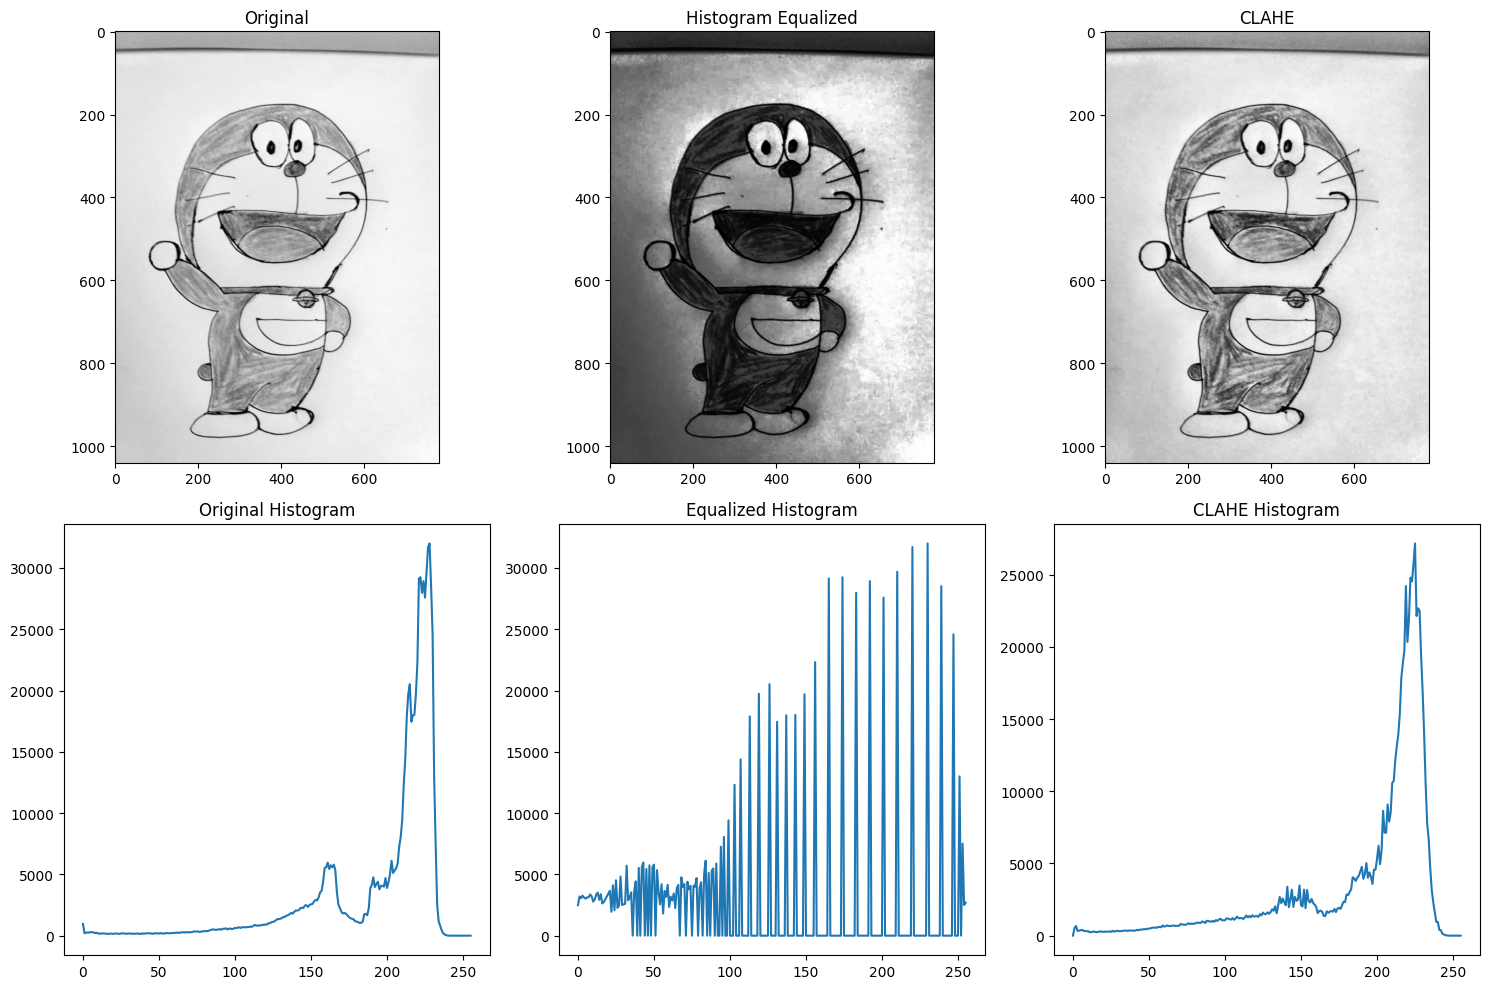

In [ ]:
### Exercise 4: Histogram Operations

### **Objective:** Analyze and modify image histograms

### **Tasks to Complete:**
### 1. Calculate and plot image histograms
### 2. Apply histogram equalization
### 3. Implement adaptive histogram equalization (CLAHE)
### 4. Compare original and enhanced images

import matplotlib.pyplot as plt

# Load grayscale image
gray = cv2.imread('/opt/Dora.jpeg', 0)

# Calculate histogram
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

# Histogram Equalization
equalized = cv2.equalizeHist(gray)

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original image and histogram
axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[1, 0].plot(hist)
axes[1, 0].set_title('Original Histogram')

# Equalized image and histogram
axes[0, 1].imshow(equalized, cmap='gray')
axes[0, 1].set_title('Histogram Equalized')
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_eq)
axes[1, 1].set_title('Equalized Histogram')

# CLAHE image and histogram
axes[0, 2].imshow(clahe_img, cmap='gray')
axes[0, 2].set_title('CLAHE')
hist_clahe = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])
axes[1, 2].plot(hist_clahe)
axes[1, 2].set_title('CLAHE Histogram')

plt.tight_layout()
plt.show()

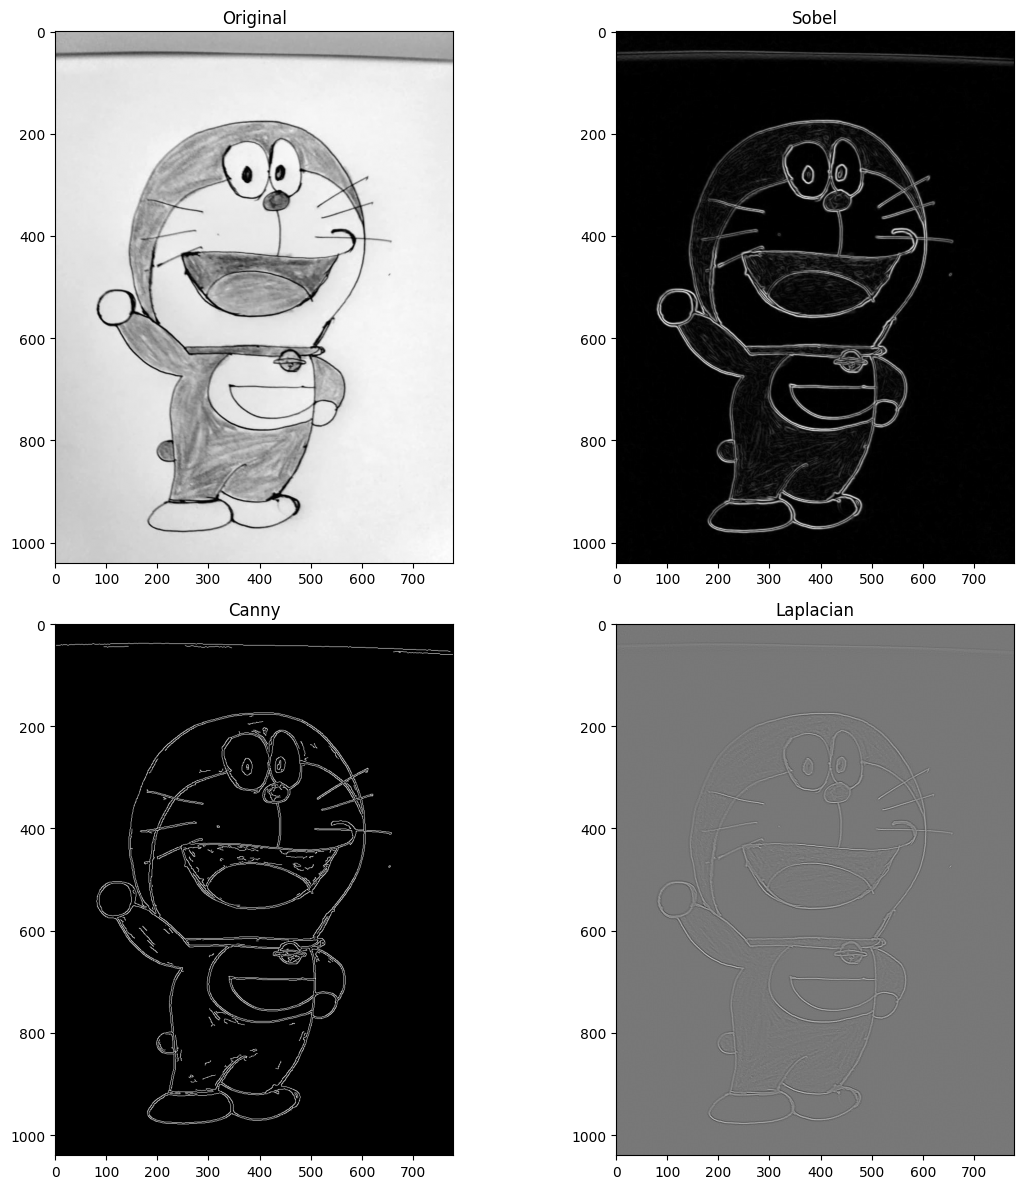

In [ ]:
## Section 3: Edge Detection & Feature Extraction

### Exercise 5: Edge Detection

### **Objective:** Detect edges using various algorithms

### **Tasks to Complete:**
### 1. Apply Sobel operator for edge detection
### 2. Use Canny edge detector
### 3. Implement Laplacian edge detection
### 4. Compare results of different methods

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
gray = cv2.imread('/opt/Dora.jpeg', 0)

# Sobel Edge Detection
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = np.sqrt(sobelx**2 + sobely**2)

# Canny Edge Detection
edges = cv2.Canny(gray, 100, 200)

# Laplacian Edge Detection
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 1].imshow(sobel_combined, cmap='gray')
axes[0, 1].set_title('Sobel')
axes[1, 0].imshow(edges, cmap='gray')
axes[1, 0].set_title('Canny')
axes[1, 1].imshow(laplacian, cmap='gray')
axes[1, 1].set_title('Laplacian')
plt.tight_layout()
plt.show()

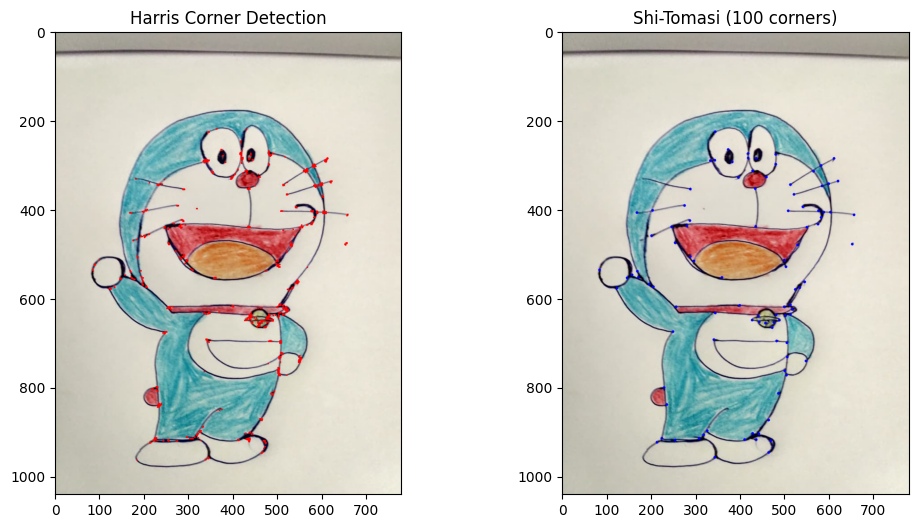

In [ ]:
### Exercise 6: Corner Detection

###  **Objective:** Detect corners and key points

###  **Tasks to Complete:**
###  1. Implement Harris corner detection
###  2. Use Shi-Tomasi corner detector
###  3. Mark detected corners on the image
### 4. Count and analyze corner distribution

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/opt/Dora.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Harris Corner Detection
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate to mark the corners
harris = cv2.dilate(harris, None)
img_harris = img.copy()
img_harris[harris > 0.01 * harris.max()] = [0, 0, 255]

# Shi-Tomasi Corner Detection
corners = cv2.goodFeaturesToTrack(gray, 100, 0.01, 10)
corners = np.int32(corners)

img_shi = img.copy()
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img_shi, (x, y), 3, (255, 0, 0), -1)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.subplot(122)
plt.imshow(cv2.cvtColor(img_shi, cv2.COLOR_BGR2RGB))
plt.title(f'Shi-Tomasi ({len(corners)} corners)')
plt.show()

Total contours found: 360
Contour 0: Area = 770068.00, Perimeter = 3559.14
Contour 1: Area = 9.50, Perimeter = 11.90
Contour 2: Area = 2.00, Perimeter = 5.66
Contour 3: Area = 34.50, Perimeter = 24.73
Contour 4: Area = 32.00, Perimeter = 24.14


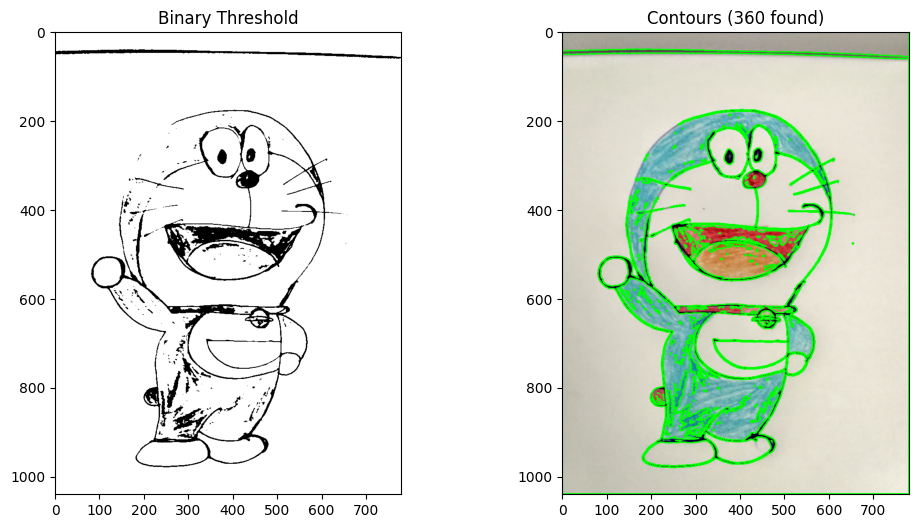

In [ ]:
## Section 4: Object Detection & Segmentation

### Exercise 7: Contour Detection

### **Objective:** Find and draw contours in images

### **Tasks to Complete:**
### 1. Convert image to binary using thresholding
### 2. Find contours in the binary image
### 3. Draw contours on the original image
### 4. Calculate contour properties (area, perimeter)

# Load image and convert to grayscale
img = cv2.imread('/opt/Dora.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply threshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, hierarchy = cv2.findContours(thresh,
                                       cv2.RETR_TREE,
                                       cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Calculate and print contour properties
print(f"Total contours found: {len(contours)}")
for i, cnt in enumerate(contours[:5]):  # Show first 5
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    print(f"Contour {i}: Area = {area:.2f}, Perimeter = {perimeter:.2f}")

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(thresh, cmap='gray')
plt.title('Binary Threshold')
plt.subplot(122)
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title(f'Contours ({len(contours)} found)')
plt.show()

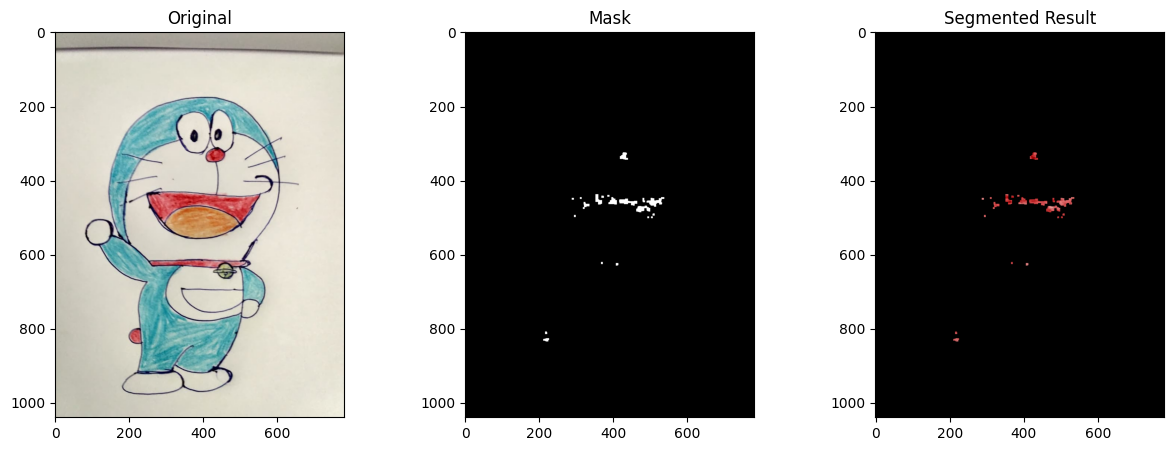

In [ ]:
### Exercise 8: Color-based Segmentation

### **Objective:** Segment objects based on color

### **Tasks to Complete:**
### 1. Convert image to HSV color space
### 2. Define color range for target object
### 3. Create mask and extract object
### 4. Apply morphological operations to improve mask

# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Define color range (example: red color)
lower_red = np.array([0, 100, 100])
upper_red = np.array([10, 255, 255])

# Create mask
mask = cv2.inRange(hsv, lower_red, upper_red)

# Morphological operations to clean up mask
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Apply mask to extract object
result = cv2.bitwise_and(img, img, mask=mask)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title('Segmented Result')
plt.show()


#### **Common HSV Color Ranges:**
#### - Red: [0, 100, 100] to [10, 255, 255]
#### - Green: [40, 40, 40] to [80, 255, 255]
#### - Blue: [100, 50, 50] to [130, 255, 255]
#### - Yellow: [20, 100, 100] to [30, 255, 255]

Found 0 faces


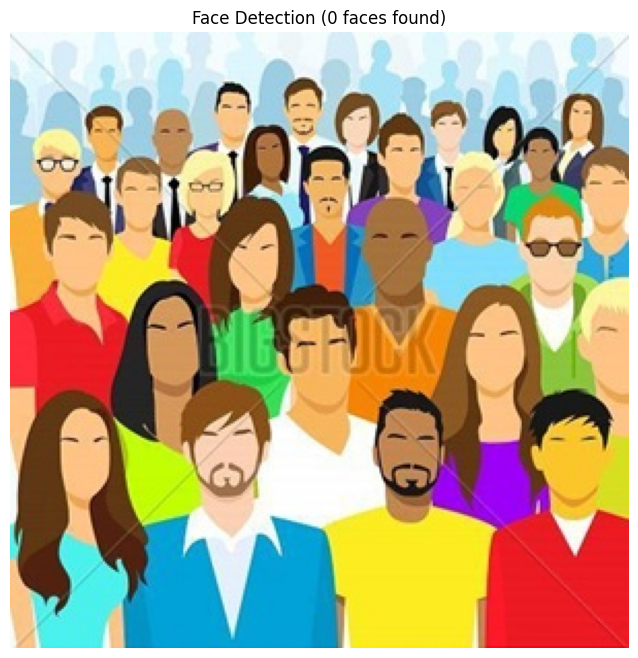

In [19]:
### Exercise 9: Face Detection (Haar Cascades)

### **Objective:** Detect faces in images using pre-trained models

### **Tasks to Complete:**
### 1. Load Haar Cascade classifier for face detection
### 2. Detect faces in an image
### 3. Draw rectangles around detected faces
### 4. Extract and save detected face regions

img = cv2.imread('/opt/people.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load Haar Cascade classifier
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray,
                                      scaleFactor=1.3,
                                      minNeighbors=5,
                                      minSize=(30, 30))

# Draw rectangles around faces
img_faces = img.copy()
for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(img_faces, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(img_faces, f'Face {i+1}', (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Extract face region
    face_roi = img[y:y+h, x:x+w]
    # Optionally save: cv2.imwrite(f'face_{i}.jpg', face_roi)

print(f"Found {len(faces)} faces")

# Display result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_faces, cv2.COLOR_BGR2RGB))
plt.title(f'Face Detection ({len(faces)} faces found)')
plt.axis('off')
plt.show()

In [1]:
import cv2

## Section 5: Video Processing & Real-time Applications

### Exercise 10: Video Capture and Processing

### **Objective:** Process video streams frame by frame

### **Tasks to Complete:**
### 1. Capture video from webcam
### 2. Apply real-time filters to video stream
### 3. Save processed video to file
### 4. Add text/overlays to video frames

# Video capture from a file (replace 'your_video.mp4' with your video file path)
# cap = cv2.VideoCapture(0) # Original for webcam
video_path = '/opt/FPS.mp4' # <--- Specify your video file path here
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video file: {video_path}")
    exit()

# Optional: Save video
fourcc = cv2.VideoWriter_fourcc(*'XVID')
# Get video properties to set up output writer correctly
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter('output.avi', fourcc, fps, (frame_width, frame_height))

while True:
    ret, frame = cap.read()
    if not ret:
        print("End of video stream or failed to read frame.")
        break

    # Apply processing (example: grayscale conversion)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    colored_gray = cv2.cvtColor(gray_frame, cv2.COLOR_GRAY2BGR)

    # Add text overlay
    cv2.putText(colored_gray, 'Live Video - Press Q to quit',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (0, 255, 0), 2)

    # Display frame (Note: cv2.imshow may not work directly in all Colab environments without additional setup like `google.colab.patches.cv2_imshow` or displaying with matplotlib)
    # cv2.imshow('Video', colored_gray)

    # Save frame
    out.write(colored_gray)

    # Exit on 'q' press (Note: cv2.waitKey may not register input in all Colab environments)
    # if cv2.waitKey(1) & 0xFF == ord('q'):
    #     break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Processed video saved to output.avi")


### **Try These Filters:**
### - Edge detection: `edges = cv2.Canny(gray_frame, 100, 200)`
### - Blur: `blur = cv2.GaussianBlur(frame, (15, 15), 0)`
### - Color inversion: `inverted = cv2.bitwise_not(frame)`

End of video stream or failed to read frame.
Processed video saved to output.avi


In [1]:
import cv2

### Exercise 11: Motion Detection

### **Objective:** Detect motion in video streams

### **Tasks to Complete:**
### 1. Capture consecutive frames
### 2. Calculate frame difference
### 3. Apply threshold to detect motion
### 4. Draw bounding boxes around moving objects

# Video capture from a file (replace 'your_video.mp4' with your video file path)
# cap = cv2.VideoCapture(0) # Original for webcam
video_path = '/opt/FPS.mp4' # <--- Specify your video file path here
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video file: {video_path}")
    exit()

# Read first two frames
ret, frame1 = cap.read()
if not ret:
    print("Error: Could not read frame from video source. Please ensure a video file is provided and accessible.")
    cap.release()
    cv2.destroyAllWindows()
    exit()

ret, frame2 = cap.read()
if not ret:
    print("Error: Could not read second frame from video source. Please ensure a video file is provided and accessible.")
    cap.release()
    cv2.destroyAllWindows()
    exit()

while True:
    # Calculate difference between frames
    diff = cv2.absdiff(frame1, frame2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold to get binary image
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    # Dilate to fill gaps
    dilated = cv2.dilate(thresh, None, iterations=3)

    # Find contours of moving objects
    contours, _ = cv2.findContours(dilated,
                                    cv2.RETR_TREE,
                                    cv2.CHAIN_APPROX_SIMPLE)

    # Draw bounding boxes around motion
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:  # Filter small movements
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(frame1, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame1, 'Motion Detected', (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Display (Note: cv2.imshow may not work directly in all Colab environments without additional setup like `google.colab.patches.cv2_imshow` or displaying with matplotlib)
    # cv2.imshow('Motion Detection', frame1)
    # cv2.imshow('Threshold', thresh)

    # Update frames
    frame1 = frame2
    ret, frame2 = cap.read()

    if not ret:
        print("End of video stream or failed to read frame.")
        break

    # if cv2.waitKey(1) & 0xFF == ord('q'): # Note: cv2.waitKey may not register input in all Colab environments
    #     break

cap.release()
cv2.destroyAllWindows()

End of video stream or failed to read frame.


In [ ]:
## Mini Projects

### Project 1: Document Scanner
###  Build a complete document scanner with these features:
### - Detect document edges using contour detection
### - Apply perspective transformation to get top-down view
### - Enhance image with adaptive thresholding
### - Save scanned document

### **Hints:**
### - Use Canny edge detection
### - Find largest rectangular contour
### - Use `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()`

### Project 2: Real-time Color Object Tracker
### Create an application that tracks colored objects:
### - Allow user to select target color by clicking
### - Track object position across frames
### - Draw trajectory of movement
### - Calculate object speed

### **Hints:**
### - Use HSV color space for better color detection
### - Store previous positions in a list
### - Use `cv2.polylines()` for trajectory


### Project 3: License Plate Detector
### Build a basic license plate detection system:
### - Convert image to grayscale
### - Apply edge detection
### - Find rectangular contours with appropriate aspect ratio
### - Extract and display detected plates

### **Hints:**
### - License plates have specific width/height ratios (typically 2:1 to 4:1)
### - Use morphological operations to clean edges
### - Filter contours by area and aspect ratio

### Project 4: Photo Filter Application
### Create an Instagram-like filter application:
### - Load image from file
### - Apply multiple artistic filters
### - Allow user to adjust filter intensity
### - Save filtered images

### **Filter Ideas:**
### - Sepia tone effect
### - Vintage effect (reduce saturation, add vignette)
### - HDR effect (tone mapping)
### - Cartoon effect (bilateral filter + edge detection)

## Challenge Exercises

### Challenge 1: Parking Space Detector
### Combine multiple techniques to detect empty parking spaces:
### - Define parking space regions
### - Use background subtraction
### - Apply motion detection
### - Count available spaces


### Challenge 2: Image Stitching for Panoramas
### Create panoramic images from multiple photos:
### - Detect keypoints using SIFT/ORB
### - Match features between images
### - Compute homography matrix
### - Blend images seamlessly

python
import cv2
import numpy as np

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Load two images
img1 = cv2.imread('image1.jpg')
img2 = cv2.imread('image2.jpg')

# Find keypoints and descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Match features
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Apply ratio test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

# Find homography and stitch
# (Complete this part as challenge)

### Challenge 3: Background Subtraction for Surveillance
### Implement intelligent background subtraction:
### - Build background model from initial frames
### - Detect foreground objects
### - Track moving objects
### - Generate alerts for unusual activity


### Challenge 4: Simple OCR System
### Build a basic optical character recognition system:
### - Preprocess image (threshold, denoise)
### - Segment individual characters
### - Use template matching or ML for recognition
### - Output recognized text

## Resources for Further Learning

### Documentation
### - **OpenCV Documentation:** docs.opencv.org
### - **NumPy User Guide:** numpy.org/doc
### - **Matplotlib Tutorials:** matplotlib.org/tutorials

### Online Courses & Tutorials
### - **PyImageSearch:** Comprehensive computer vision tutorials
### - **Kaggle Learn:** Free computer vision courses
### - **Coursera:** Computer Vision Specialization
### - **YouTube:** sentdex, PyImageSearch channels

### Datasets for Practice
### - **COCO Dataset:** Object detection and segmentation
### - **ImageNet:** Image classification
### - **CIFAR-10/100:** Small image classification
### - **Kaggle Datasets:** Various computer vision challenges

### Advanced Topics to Explore
### - Deep Learning for Computer Vision (CNNs, YOLO, R-CNN)
### - 3D Computer Vision and Depth Estimation
### - Semantic Segmentation
### - Pose Estimation
### - Face Recognition with Deep Learning
### - Video Analysis and Action Recognition

## Tips for Success

### 1. **Start Simple:** Master basic operations before moving to complex tasks
### 2. **Experiment:** Try different parameters and see their effects
### 3. **Visualize:** Always display intermediate results to understand pipeline
### 4. **Debug:** Print shapes and data types when encountering errors
### 5. **Practice:** Work on mini-projects to solidify concepts
### 6. **Read Documentation:** OpenCV docs have excellent examples
### 7. **Join Communities:** Reddit r/computervision, Stack Overflow, GitHub

## Common Issues and Solutions

### Issue: Image not loading
# Always check if image loaded successfully
img = cv2.imread('image.jpg')
if img is None:
    print("Error: Could not load image")


### Issue: Color mismatch in display
# OpenCV uses BGR, Matplotlib uses RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)


### Issue: Video capture not working

# Check if camera opened successfully
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open camera")

## Appendix: Quick Reference

### Common OpenCV Functions

# Reading/Writing
cv2.imread(filename)
cv2.imwrite(filename, img)
cv2.VideoCapture(source)

# Color Conversion
cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Transformations
cv2.resize(img, (width, height))
cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
cv2.flip(img, flipCode)

# Filtering
cv2.GaussianBlur(img, (ksize, ksize), sigma)
cv2.medianBlur(img, ksize)
cv2.bilateralFilter(img, d, sigmaColor, sigmaSpace)

# Edge Detection
cv2.Canny(img, threshold1, threshold2)
cv2.Sobel(img, ddepth, dx, dy)
cv2.Laplacian(img, ddepth)

# Morphological Operations
cv2.erode(img, kernel)
cv2.dilate(img, kernel)
cv2.morphologyEx(img, operation, kernel)

# Contours
cv2.findContours(img, mode, method)
cv2.drawContours(img, contours, idx, color, thickness)
cv2.contourArea(contour)
cv2.arcLength(contour, closed)

# Drawing
cv2.line(img, pt1, pt2, color, thickness)
cv2.rectangle(img, pt1, pt2, color, thickness)
cv2.circle(img, center, radius, color, thickness)
cv2.putText(img, text, org, font, scale, color, thickness)